# Notebook 01 - Linear Regression Model

This notebook follows the [Linear Regression from Scratch in Python](https://www.youtube.com/watch?v=VmbA0pi2cRQ) video. 
<br>Data is sourced from Kaggle.

# 1. Package and data import

In [2]:
# Package import
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Download latest version of data from Kaggle API
kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression", output_dir='./data')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'./data'

In [3]:
# Import data into Juputer file
df = pd.read_csv('data/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# 2. Defining variables and functions

## 2.1 Defining variables

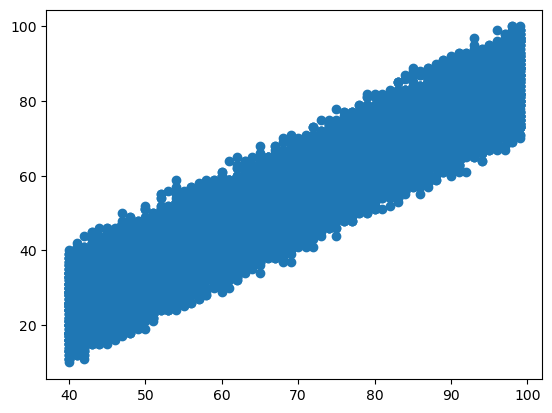

In [4]:
# Variables of interest: 
performance_index = df['Performance Index']
prev_scores = df['Previous Scores']

points = df[['Previous Scores', 'Performance Index']]
# plt.scatter(hours_studied, performance_index)
# plt.scatter(sleep_hours, performance_index)

plt.scatter(points['Previous Scores'], points['Performance Index'])

### 2.1.1 Data normalization

In [5]:
points['Performance Index'].describe()
points['Previous Scores'].describe()


# Min max normalization
min = points['Performance Index'].min()
max = points['Performance Index'].max()
points['norm_perfIndex'] = (points['Performance Index']-min)/(max - min)

min = points['Previous Scores'].min()
max = points['Previous Scores'].max()
points['norm_prevScore'] = (points['Previous Scores']-min)/(max - min)

points['norm_prevScore'].describe()


/var/folders/km/yjwvs1v17s53cm1j806_1chc0000gn/T/ipykernel_3702/2188153900.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  points['norm_perfIndex'] = (points['Performance Index']-min)/(max - min)
/var/folders/km/yjwvs1v17s53cm1j806_1chc0000gn/T/ipykernel_3702/2188153900.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  points['norm_prevScore'] = (points['Previous Scores']-min)/(max - min)


count    10000.000000
mean         0.499080
std          0.293952
min          0.000000
25%          0.237288
50%          0.491525
75%          0.762712
max          1.000000
Name: norm_prevScore, dtype: float64

## 2.2 Defining functions

In [6]:
# Loss function
def loss_function(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points['Previous Scores'].iloc[i]
        y = points['Performance Index'].iloc[i]
        total_error += (y - (m * x + b))**2
    total_error = total_error / float(len(points))
    return total_error

# gradient descent function
# Pass in: current m value, current b value, df with previous scores and performance indices.
# Return: new m, new b
# Purpose: Return new m and b values in the direction of steepest descent and multiplied by the learning rate.
def new_gradient(m_now, b_now, points, L):
    # inital values
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x_i = points['Previous Scores'].iloc[i]
        y_i = points['Performance Index'].iloc[i]

        # Summation from error function
        m_gradient += -2/n * x_i * (y_i - (m_now * x_i + b_now)) # change in the m value (before L)
        b_gradient += -2/n * (y_i - (m_now * x_i + b_now)) # change in the b value (before L)
    
    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b


# Normalized functions
def norm_loss(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points['norm_prevScore'].iloc[i]
        y = points['norm_perfIndex'].iloc[i]
        total_error += (y - (m * x + b))**2
    total_error = total_error / float(len(points))
    return total_error

def norm_gradient(m_now, b_now, points, L):
    # inital values
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x_i = points['norm_prevScore'].iloc[i]
        y_i = points['norm_perfIndex'].iloc[i]

        # Summation from error function
        m_gradient += -2/n * x_i * (y_i - (m_now * x_i + b_now)) # change in the m value (before L)
        b_gradient += -2/n * (y_i - (m_now * x_i + b_now)) # change in the b value (before L)
    
    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b

In [7]:
points.iloc[2, 0]

np.int64(51)

# 3. Applying regression functions

In [8]:
print(df.describe())

       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

epoch: 0
0 0
Error: 0.2980701234567819
epoch: 50
0.2310104429518421 0.32719111210220647
Error: 0.027247905394077655
epoch: 100
0.29715318570579347 0.35669172065999766
Error: 0.01907449887973052
epoch: 150
0.3363578535845974 0.34504244527571915
Error: 0.016820069796380743
epoch: 200
0.3687957632388034 0.32901495511931306
Error: 0.01507436079150455
epoch: 250
0.39765232663590133 0.3137533672971915
Error: 0.013653741387891626
epoch: 300
0.42363987040165313 0.2998625013560947
Error: 0.012496170929321973
epoch: 350
0.44708994735546936 0.28730679892728145
Error: 0.011552910789806832
epoch: 400
0.46825700294954264 0.2759704294276773
Error: 0.0107842833318028
epoch: 450
0.48736426715914416 0.2657367765842318
Error: 0.010157957510230234
epoch: 500
0.5046123193495868 0.25649883524024475
Error: 0.009647587979585696
epoch: 550
0.5201820881273165 0.24815976216182217
Error: 0.009231706901651046
epoch: 600
0.5342368780063321 0.24063210121975287
Error: 0.008892820936484327
epoch: 650
0.546924100777962

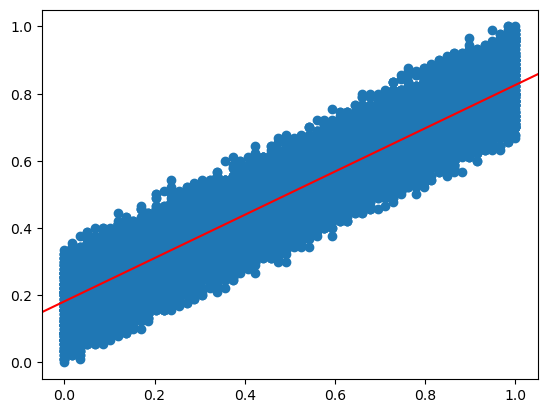

In [12]:
# Redoing with normalized values

m = 0
b = 0
L = 0.015   #'step' size
epochs = 1500   #number of iterations

# best so far: L = 0.005, epochs = 300

# Lists of 
m_list = []
b_list = []

for i in range(epochs):
    if i % 50 == 0:
        print(f'epoch: {i}')
        print(m, b)
        print("Error:", norm_loss(m, b, points))
    m, b = norm_gradient(m, b, points, L)
    
    m_list.append(m)
    b_list.append(b)
estimators = pd.DataFrame({"m": m_list, 
                           "b": b_list})
estimators.reset_index(drop=True, inplace=True)

error = norm_loss(m, b, points)

print("final m:", round(m, 3), "b:", round(b, 3))
print("error:", error)

plt.scatter(points['norm_prevScore'], points['norm_perfIndex'])
#plt.plot(list(range(0, 1, 0.1)), [m * x + b for x in range(0, 1, 0,1)], color='red')
plt.axline((0, b), slope=m, color='red')



In [10]:
# # Defining starting and iteration values

# m = 0
# b = 0
# L = 0.00013   #'step' size
# epochs = 2000   #number of iterations

# # best so far: L = 0.005, epochs = 300

# # Lists of 
# m_list = []
# b_list = []

# for i in range(epochs):
#     if i % 50 == 0:
#         print(f'epoch: {i}')
#         print(m, b)
#         print("Error:",loss_function(m, b, points))
#     m, b = new_gradient(m, b, points, L)
    
#     m_list.append(m)
#     b_list.append(b)
# estimators = pd.DataFrame({"m": m_list, 
#                            "b": b_list})
# estimators.reset_index(drop=True, inplace=True)

# error = loss_function(m, b, points)

# print("final m:", round(m, 3), "b:", round(b, 3))
# print("error:", error)

# plt.scatter(points['Previous Scores'], points['Performance Index'])
# plt.plot(list(range(0, 99)), [m * x + b for x in range(0, 99)], color='red')


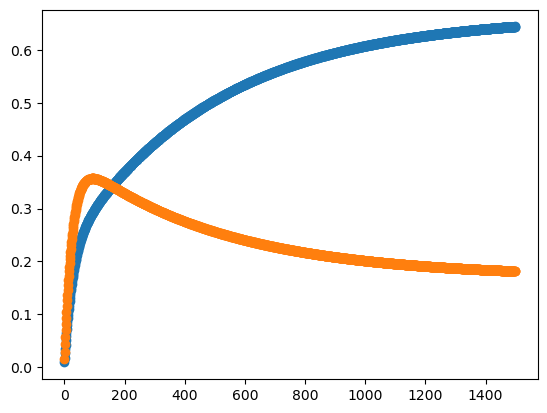

In [13]:
plt.scatter(estimators.index, estimators['m'])
plt.scatter(estimators.index, estimators['b'])